In today's tutorial you will practice the object-oriented programming concept of **abstraction**. You will apply this concept to calculating simple statistics (mean, variance, t-value) and obtaining confidence intervals in a procedure called **boostrapping**. The tutorial is linked to your course on **Probability theory**.

If you haven't attended the lecture, here are the key elements you'll need today:
- **Abstract classes** enable defining classes that have a repertoire of methods - however not all of them are defined.
- The methods that have actual code are called **concrete methods**.
- Those that do not have code yet serve as placeholders for future code and are also called **abstract methods**.

In [1]:
from abc import ABC, abstractmethod # ABC = Abstract Base Class

class Animal(ABC): # Abstract class

    def eat(self):  # Concrete method: has code
        print("Eating...")

    @abstractmethod
    def sound(self):  # Abstract method: placeholder for code
        pass

If you want to instantiate an object of an abstract class, all methods need to be concrete. The code below will give you an error.

In [2]:
cat = Animal()
cat.eat()

TypeError: Can't instantiate abstract class Animal without an implementation for abstract method 'sound'

If you create a subclass of the abstract class:
 - all methods are inherited (as usual)
 - abstract methods need to be replaced with concrete methods

In that case you can instantiate an object of the subclass.

In [3]:
class Dog(Animal): # Subclass
    def sound(self): # Specifying the method (making it concrete)
        print("Bark!")

puppy = Dog() # instantiating a class
puppy.eat()    # Inherited concrete method
puppy.sound()  # Implemented abstract method

Eating...
Bark!


The point of abstraction is to create a coherent set of classes where you require each subclass to define a specified set of methods.

Let's now translate it to simple statistics. Let's start by defining an abstract method that will work on some data. (For simplicity, let's assume that "data" is a list of numbers). Please reshuffle the lines to create a working definition.

In [4]:
from abc import ABC, abstractmethod
class Statistics(ABC):
    @abstractmethod
    def description(self):
        pass
        
    @abstractmethod
    def compute(self, data):
        pass
    
    
    

Now, create a subclass of "Statistics" called "Mean". Please complete the code below (without using Numpy or other packages).

In [13]:
class Mean(Statistics):
    def compute(self, data):
        # COMPLETE THIS LINE OF CODE
        average = sum(data)/len(data)
        return average

    def description(self):
        return "The mean of the dataset is "

Now let's test it:

In [14]:
my_data = [1, 2, 3, 4, 5]
mean_stat = Mean()
print(mean_stat.description() + str(mean_stat.compute(my_data)))

The mean of the dataset is 3.0


In the remaining part of the notebook, we will work with "datasets" composed of random numbers. More specifically, we will use random numbers drawn from Gaussian distributions. Gaussian distributions are defined by their mean and standard deviation. What is the mean of the red and blue line? How about the standard deviation?

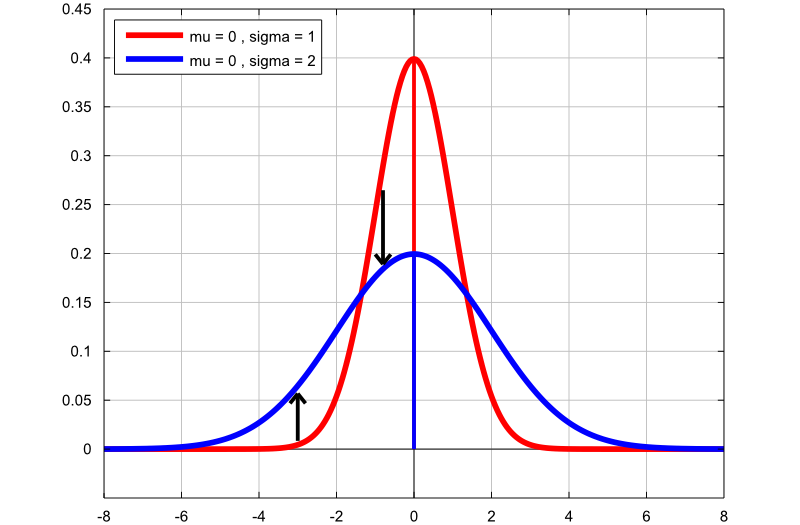

Standard deviation is related to **variance**. How would you implement a new subclass of Statistics called "Variance" that would work on the same dataset? Please write your code below according to the following instructions:
- use the Mean() class inside of your Variance(Statistics) class
- don't use Numpy or other toolboxes

For your reference, here's the formula for calculating variance:

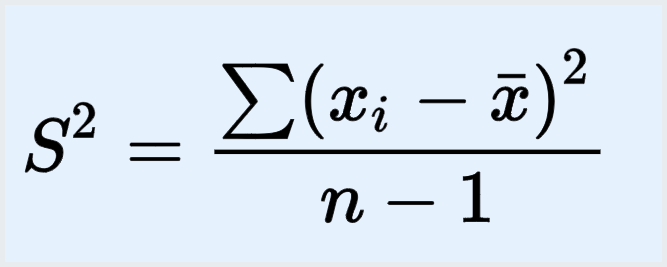

where:
- *$S^{2}$* is the variance of your sample (dataset)
- *$x_{i}$* is the i-th element of the dataset
- *x̄* is the mean of the dataset
- *N* is the number of elements in the dataset

In [33]:
# WRITE YOUR CODE
class Variance(Statistics):
    def compute(self, data):
        
        # Compute mean
        mean_calculator = Mean()
        mean_value = mean_calculator.compute(data)

        # Compute variance
        squared_diff = [(element - mean_value) **2 for element in data]
        sum_squared_diff = sum(squared_diff)
        variance = sum_squared_diff / (len(data)-1)
        
        return variance

    def description(self):
        return "The variance of the dataset is "

Let's test it:

In [34]:
import random
my_data = [random.gauss(0, 100) for _ in range(100)] # draw numbers from a distribution with mean 0 and standard deviation 2
my_variance = Variance()
print(my_variance.description() + str(my_variance.compute(my_data)))

The variance of the dataset is 8776.568110069886


Mean and variance (or related quantities such as standard deviation and standard error) are useful in comparing two distributions. For example, if you want to test if two datasets are significantly different from each other, you may use a T-test. A T-test is quantified by a T-statistic (also known as T-value), among other quantities (such as degrees of freedom and a p-value, which we won't look into today).

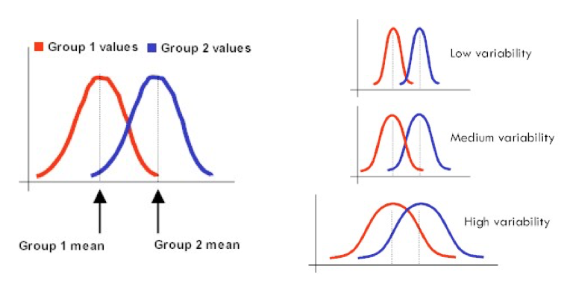

On the right you see three examples. The difference in means are the same for all three examples. However the variance (variability) changes from top to bottom panel. Which of these three examples has the largest chance of showing a significant difference?

Now please implement a new subclass of Statistics called "TValue". This will return a T-value (i.e. the summary statistic of a T-test). For simplicity let's only implement an two-sample T-test for independent samples. Please complete your code below according to the following instructions:

- use the Mean() and Variance() classes inside of your TValue(Statistics) class
- don't use Numpy, scipy etc.
- you can import *sqrt* (square root) from *math*
- Tvalue.compute() should take *data1* and *data2* as inputs and return *t_stat* as output.

Here's the formula for your reference:

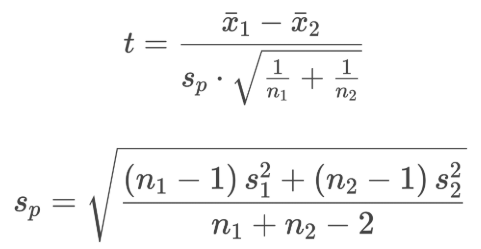

where:
- *$s_{p}$* is the pooled standard deviation
- the entire denominator of the first equation is the pooled standard error
- *$x_{1}$* is the 1st dataset
- *$n_{1}$* is the number of elements in the 1st dataset
- *$s_{1}^{2}$* is the variance of the 1st dataset
- *$x_{2}$* is the 2nd dataset
- *$n_{2}$* is the number of elements in the 2nd dataset
- *$s_{2}^{2}$* is the variance of the 2nd dataset

In [43]:
import math

class TValue(Statistics):
    def compute(self, data1, data2):
        n1, n2 = len(data1), len(data2)

        # Use Mean and Variance classes
        mean_calc = Mean()        
        var_calc = Variance()

        mean1 = mean_calc.compute(data1)
        mean2 = mean_calc.compute(data2)

        # Adjust population variance to sample variance
        var1 = var_calc.compute(data1) * n1 / (n1 - 1)
        var2 = var_calc.compute(data2) * n2 / (n2 - 1)

        # Pooled standard deviation and standard error
        pooled_std = math.sqrt(((n1 - 1) * var1 + (n2 - 1) * var2) / (n1 + n2 - 2))
        standard_error = pooled_std * math.sqrt((1/n1 + 1/n2))

        t_stat = (mean1-mean2) / standard_error
        return t_stat

    def description(self):
        return "The t-value of two independent samples is "

Let's test it:

In [44]:
data1 = [random.gauss(-1, 2) for _ in range(100)]
data2 = [random.gauss(1, 2) for _ in range(100)]

t_value = TValue()
print(t_value.description() + str(t_value.compute(data1, data2)))

The t-value of two independent samples is -8.586976003004922


***OPTIONAL***

Finally let's use a technique called **bootstrapping** to calculate **confidence intervals** of a statistic of your choice (e.g. mean, t-value etc.)

Usually we calculate statistics to say something about the **population**, not just one **sample** (dataset). Sure, if we only have 5 elements in a sample, it's very easy to calculate the mean. But with only one small sample, you don't know **how much your result might vary if you had taken a different sample from the population**. Bootstrapping tells you how much the sample mean might fluctuate if you *could* collect other samples. Here's how it works:

- Bootstrapping estimates the confidence intervals of a sample statistic (e.g. mean) by repeatedly resampling the data with replacement.
- Each resample, called a bootstrap sample, is the same size as the original dataset and is used to compute the statistic again.
- By doing this many times, bootstrapping creates an empirical distribution of the statistic.
- From this distribution, **confidence intervals** are calculated by identifying the range within which a certain percentage (e.g. 95%) of the resampled statistics fall, giving a data-driven measure of uncertainty.

Here's how it looks in code:

In [1]:
import random
import numpy as np

class BootstrapMean(Statistics):
    def compute(self, data, num_samples=1000, ci_percentile=95):
        # Generate bootstrap samples and calculate the mean of each sample
        results = []
        mean = Mean()
        for _ in range(num_samples):
            bootstrap_sample = [random.choice(data) for _ in data]  # Use random.choice to sample with replacement
            sample_mean = mean.compute(bootstrap_sample)  # Calculate mean of the sample
            results.append(sample_mean) # Add to the empirical distribution of the statistic

        # Calculate the confidence interval
        lower, upper = np.percentile(results, [(100 - ci_percentile) / 2, 100 - (100 - ci_percentile) / 2])
        return lower, upper

    def description(self):
        return "Confidence Interval for the Mean: "

NameError: name 'Statistics' is not defined

And here's how to use it:

In [ ]:
data = [random.gauss(0, 1) for _ in range(100)]

sample_mean = Mean()
bootstrap = BootstrapMean()
lower, upper = bootstrap.compute(data, num_samples=1000, ci_percentile=95)

print(sample_mean.description() + str(round(sample_mean.compute(data),2)))
print(bootstrap.description() + str(round(lower,2)) + ', ' + str(round(upper,2)))

The mean of the dataset is -0.15
Confidence Interval for the Mean: -0.31, 0.01


***(Optional) practice:***

Write a class BootstrapTValue(Statistics) that will:
- take *data1* and *data2* as input
- return lower and upper confidence intervals for the T-statistic.

In [ ]:
# WRITE YOUR OWN CODE

The t-value of two independent samples is 0.91
Confidence Interval for the Mean: -0.93, 2.73


... and test it below:

In [ ]:
data1 = [random.gauss(0, 1) for _ in range(100)]
data2 = [random.gauss(0, 1) for _ in range(100)]

sample_t = TValue()
bootstrap = BootstrapTValue()
lower, upper = bootstrap.compute(data1, data2, num_samples=1000, ci_percentile=95)

print(sample_t.description() + str(round(sample_t.compute(data1, data2),2)))
print(bootstrap.description() + str(round(lower,2)) + ', ' + str(round(upper,2)))